In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [20]:
url = "https://github.com/erkansirin78/datasets/raw/master/housing.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [21]:
#EDA 
print("*** Data Structures ***")
print(df.dtypes)
print("\n*** NA ***")
print(df.isnull().sum())
print("\n*** Describe ***")
df.describe().T

*** Data Structures ***
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

*** NA ***
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

*** Describe ***


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


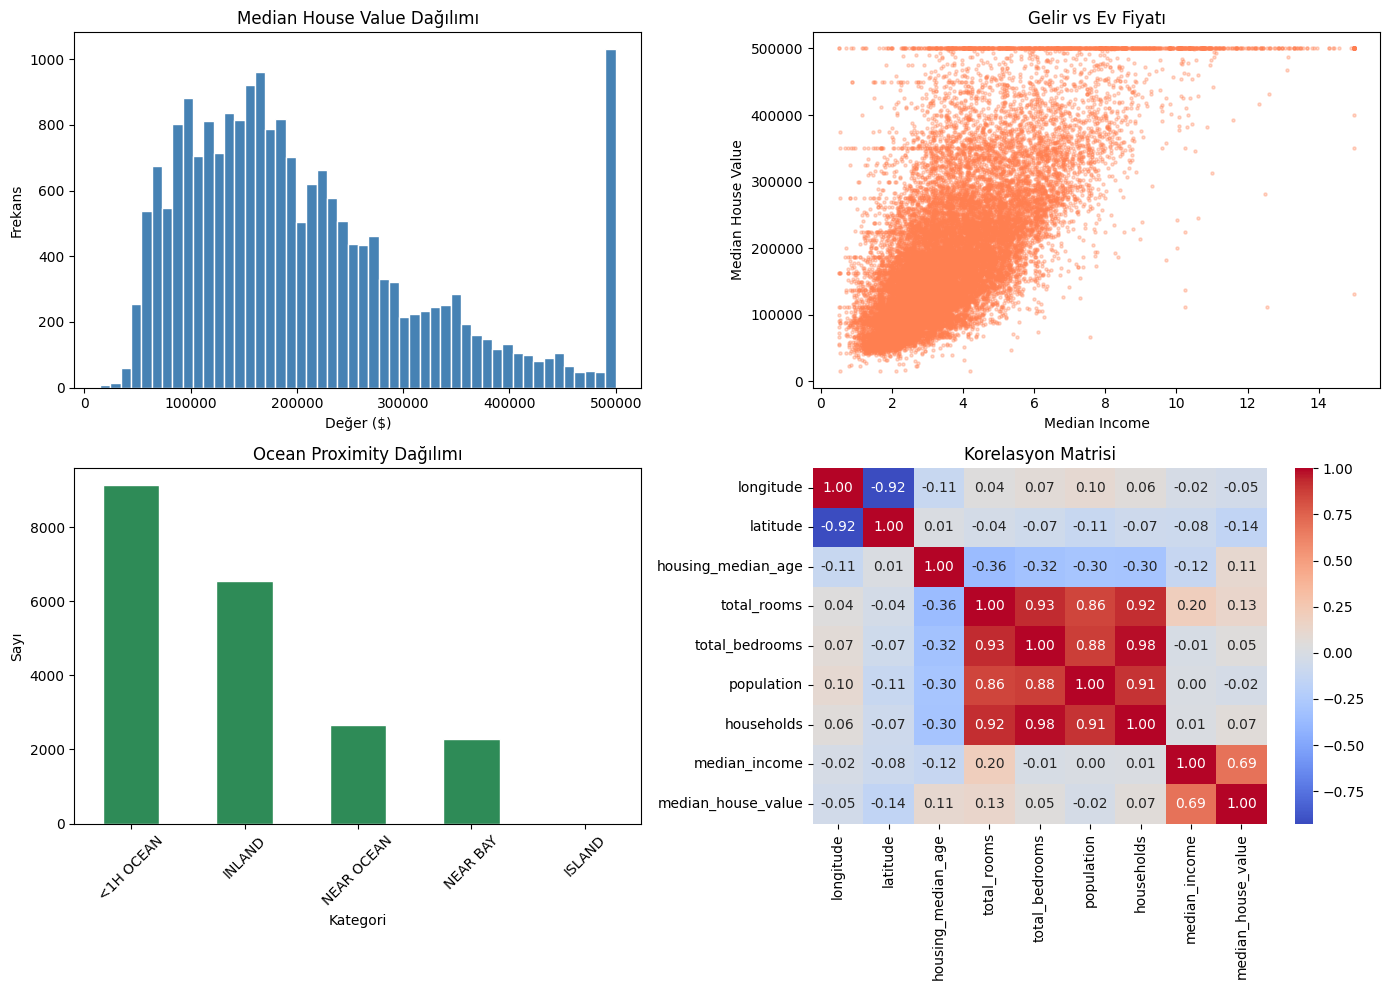

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Hedef değişken dağılımı
axes[0, 0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Median House Value Dağılımı')
axes[0, 0].set_xlabel('Değer ($)')
axes[0, 0].set_ylabel('Frekans')

# 2. Gelir vs Ev Fiyatı
axes[0, 1].scatter(df['median_income'], df['median_house_value'], alpha=0.3, color='coral', s=5)
axes[0, 1].set_title('Gelir vs Ev Fiyatı')
axes[0, 1].set_xlabel('Median Income')
axes[0, 1].set_ylabel('Median House Value')

# 3. Ocean Proximity dağılımı
df['ocean_proximity'].value_counts().plot(kind='bar', ax=axes[1, 0], color='seagreen', edgecolor='white')
axes[1, 0].set_title('Ocean Proximity Dağılımı')
axes[1, 0].set_xlabel('Kategori')
axes[1, 0].set_ylabel('Sayı')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Korelasyon Heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Korelasyon Matrisi')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#Data Preprocess

#Missing Values 
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

#Encoding categorical values 
df = pd.get_dummies(df,columns = ["ocean_proximity"],drop_first = False)

#Target Value
X = df.drop("median_house_value",axis = 1)
y = df["median_house_value"]

#Train/Test Value
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape},Test: {X_test.shape}")
print(f"Is there any missing value ? : {df.isnull().sum().sum()}")


Train : (16512, 13),Test: (4128, 13)
Is there any missing value ? : 0


In [25]:
#MLFLOW 
mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("HousingPricePrediction")

def eval_metrics(actual,pred):
    rmse = np.sqrt(mean_squared_error(actual,pred))
    mae = mean_absolute_error(actual,pred)
    r2 = r2_score(actual,pred)
    return rmse,mae,r2
    

2026/04/29 12:12:11 INFO mlflow.tracking.fluent: Experiment with name 'HousingPricePrediction' does not exist. Creating a new experiment.


In [27]:
#ElasticNet
with mlflow.start_run(run_name="ElasticNet"):
    alpha = 0.1
    l1_ratio = 0.5
    
    model1 = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    model1.fit(X_train_scaled, y_train)
    pred1 = model1.predict(X_test_scaled)
    
    rmse, mae, r2 = eval_metrics(y_test, pred1)
    
    # Log params
    mlflow.log_param("alpha", alpha)
    mlflow.log_param("l1_ratio", l1_ratio)
    
    # Log metrics
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    
    # Log model
    mlflow.sklearn.log_model(model1, "model")
    print(f"ElasticNet → RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f} ")

2026/04/29 12:15:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 12:15:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 12:15:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


ElasticNet → RMSE: 70274.85, MAE: 50771.21, R2: 0.62 
🏃 View run ElasticNet at: http://127.0.0.1:5001/#/experiments/1/runs/d5a87195134b4dd4a980fde92d1cfe9e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [28]:
#Random Forest
with mlflow.start_run(run_name="RandomForest"):
    n_estimators = 100
    max_depth = 15
    
    model2 = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model2.fit(X_train_scaled, y_train)
    pred2 = model2.predict(X_test_scaled)
    
    rmse, mae, r2 = eval_metrics(y_test, pred2)
    
    # Log params
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    
    # Log metrics
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    
    # Log model
    mlflow.sklearn.log_model(model2, "model")
    
    print(f"RandomForest → RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f} ")

2026/04/29 12:15:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 12:15:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 12:15:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


RandomForest → RMSE: 49379.72, MAE: 32187.43, R2: 0.81 
🏃 View run RandomForest at: http://127.0.0.1:5001/#/experiments/1/runs/ac62d3e7b83e4673819bba52915cfe05
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [29]:
#Gradient Boosting
with mlflow.start_run(run_name="GradientBoosting"):
    n_estimators = 100
    learning_rate = 0.1
    
    model3 = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
    model3.fit(X_train_scaled, y_train)
    pred3 = model3.predict(X_test_scaled)
    
    rmse, mae, r2 = eval_metrics(y_test, pred3)
    
    # Log params
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    
    # Log metrics
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    
    # Log model
    mlflow.sklearn.log_model(model3, "model")
    
    print(f"GradientBoosting → RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f} ")

2026/04/29 12:16:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 12:16:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/29 12:16:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


GradientBoosting → RMSE: 55881.78, MAE: 38250.02, R2: 0.76 
🏃 View run GradientBoosting at: http://127.0.0.1:5001/#/experiments/1/runs/7ce14a18ad80461d9213c8a5fe372082
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [30]:
# Save best model 
best_run_id = "ac62d3e7b83e4673819bba52915cfe05"  # RandomForest run id

model_uri = f"runs:/{best_run_id}/model"

mlflow.register_model(
    model_uri=model_uri,
    name="HousingPricePrediction-BestModel"
)

print("Model is saved")

Successfully registered model 'HousingPricePrediction-BestModel'.
2026/04/29 12:19:19 WARNING mlflow.tracking._model_registry.fluent: Run with id ac62d3e7b83e4673819bba52915cfe05 has no artifacts at artifact path 'model', registering model based on models:/m-f5baa35dfeec4929843cd8c26a996494 instead
2026/04/29 12:19:19 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousingPricePrediction-BestModel, version 1


Model is saved


Created version '1' of model 'HousingPricePrediction-BestModel'.
